# Part D: Mechanical Failure Analysis — Logistic Regression (Champion)

This notebook performs the Part D failure analysis for the selected champion model.  
The objective is to inspect the raw validation data where the model was confidently incorrect, explain the failure mechanically based on feature values, and propose targeted technical fixes.

## 1. Setup: Load Artifacts & Data

In this section, we import the required libraries, load the saved champion model artifact from the `.joblib` file, and load the prepared train/test datasets from the Data Preparation stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported.")

Libraries imported.


In [2]:
# Load champion model artifact
artifact = joblib.load("logistic_regression_baseline.joblib")
champion_pipeline = artifact["pipeline"]
champion_threshold = artifact["threshold"]
le = artifact["label_encoder"]

print("Loaded champion artifact successfully.")
print(f"Champion threshold: {champion_threshold}")
print(f"Pipeline: {champion_pipeline}")

Loaded champion artifact successfully.
Champion threshold: 0.5
Pipeline: Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(C=np.float64(0.02069138081114789),
                                    class_weight={0: 1, 1: 5}, max_iter=5000,
                                    penalty='l1', random_state=42,
                                    solver='liblinear'))])


In [3]:
# Load prepared data
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train_raw = pd.read_csv("y_train.csv").values.ravel()
y_test_raw = pd.read_csv("y_test.csv").values.ravel()

y_train = le.transform(y_train_raw)
y_test = le.transform(y_test_raw)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Positive rate (train): {np.mean(y_train):.4f}")
print(f"Positive rate (test):  {np.mean(y_test):.4f}")

X_train: (352827, 76)
X_test:  (88414, 76)
Positive rate (train): 0.0568
Positive rate (test):  0.0568


## 2. Shared Validation Helpers

Part D requires analysis on validation data rather than only on the final test set.  
To achieve this, we generate out-of-fold predicted probabilities using cross-validation so that each training instance is scored by a model that did not train on that specific instance.

This makes the failure analysis more reliable and avoids leakage.

In [4]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

TARGET_NAMES = ["No Heart Disease (0)", "Heart Disease (1)"]

def classify_from_threshold(y_proba, threshold):
    return (y_proba >= threshold).astype(int)

def get_error_type(y_true, y_pred):
    if y_true == y_pred:
        return "Correct"
    elif y_true == 1 and y_pred == 0:
        return "False Negative"
    else:
        return "False Positive"

print("Validation helpers ready.")

Validation helpers ready.


## 3. Generate Out-of-Fold Validation Predictions

In this section, we produce out-of-fold validation probabilities for the training set using the loaded champion model.  
These probabilities are then converted into thresholded decisions using the saved champion threshold from Part C.

In [5]:
oof_proba = cross_val_predict(
    champion_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

oof_pred = classify_from_threshold(oof_proba, champion_threshold)

print("OOF validation predictions generated.")
print("\nValidation classification report:")
print(classification_report(y_train, oof_pred, target_names=TARGET_NAMES))

OOF validation predictions generated.

Validation classification report:
                      precision    recall  f1-score   support

No Heart Disease (0)       0.96      0.93      0.95    332781
   Heart Disease (1)       0.27      0.42      0.33     20046

            accuracy                           0.90    352827
           macro avg       0.61      0.67      0.64    352827
        weighted avg       0.92      0.90      0.91    352827



## 4. Build the Validation Failure Table

This table stores the raw validation rows together with:
- actual label
- predicted probability score
- thresholded prediction
- failure type
- prediction confidence
- distance from threshold

This structure makes it easier to identify the most confidently wrong cases.

In [6]:
validation_results = X_train.copy()
validation_results["actual"] = y_train
validation_results["predicted_prob"] = oof_proba
validation_results["predicted_label"] = oof_pred

validation_results["error_type"] = [
    get_error_type(a, p) for a, p in zip(validation_results["actual"], validation_results["predicted_label"])
]

validation_results["prediction_confidence"] = np.where(
    validation_results["predicted_label"] == 1,
    validation_results["predicted_prob"],
    1 - validation_results["predicted_prob"]
)

validation_results["distance_from_threshold"] = np.abs(
    validation_results["predicted_prob"] - champion_threshold
)

print(validation_results["error_type"].value_counts())

error_type
Correct           318099
False Positive     23044
False Negative     11684
Name: count, dtype: int64


## 5. Extract the Most Confident Failure Cases

For classification failure analysis, the most useful cases are:
- false negatives with high confidence
- false positives with high confidence

Because this project is framed as a medical triage task, false negatives are especially important, since they represent cases where an at-risk patient was assigned a low-risk score.

In [7]:
TOP_K = 5  # change to 10 if needed

false_negatives = (
    validation_results[validation_results["error_type"] == "False Negative"]
    .sort_values("prediction_confidence", ascending=False)
    .head(TOP_K)
    .copy()
)

false_positives = (
    validation_results[validation_results["error_type"] == "False Positive"]
    .sort_values("prediction_confidence", ascending=False)
    .head(TOP_K)
    .copy()
)

print("=" * 80)
print("TOP FALSE NEGATIVES (most confidently missed positive cases)")
print("=" * 80)
display(false_negatives[[
    "actual", "predicted_label", "predicted_prob",
    "prediction_confidence", "distance_from_threshold"
]])

print("=" * 80)
print("TOP FALSE POSITIVES (most confidently over-flagged negative cases)")
print("=" * 80)
display(false_positives[[
    "actual", "predicted_label", "predicted_prob",
    "prediction_confidence", "distance_from_threshold"
]])

TOP FALSE NEGATIVES (most confidently missed positive cases)


,actual,predicted_label,predicted_prob,prediction_confidence,distance_from_threshold
103776,1,0,0.005759,0.994241,0.494241
210277,1,0,0.005913,0.994087,0.494087
47087,1,0,0.006644,0.993356,0.493356
91807,1,0,0.006991,0.993009,0.493009
332210,1,0,0.007065,0.992935,0.492935


TOP FALSE POSITIVES (most confidently over-flagged negative cases)


,actual,predicted_label,predicted_prob,prediction_confidence,distance_from_threshold
291833,0,1,0.973189,0.973189,0.473189
8554,0,1,0.970346,0.970346,0.470346
10239,0,1,0.968212,0.968212,0.468212
275764,0,1,0.967903,0.967903,0.467903
107253,0,1,0.966517,0.966517,0.466517


## 6. Fit the Champion Model on the Full Training Data for Interpretation

Out-of-fold predictions are used to identify the failures, but to analyse feature contributions in a stable way, we fit the saved champion pipeline on the full training data.

This gives us access to the trained logistic regression coefficients for interpretation.

In [8]:
interpret_model = champion_pipeline
interpret_model.fit(X_train, y_train)

scaler = interpret_model.named_steps["scaler"]
logreg = interpret_model.named_steps["logreg"]

feature_names = X_train.columns.tolist()
coefficients = logreg.coef_[0]
intercept = logreg.intercept_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "AbsCoefficient": np.abs(coefficients)
}).sort_values("AbsCoefficient", ascending=False)

print("Top 20 features by absolute coefficient:")
display(coef_df.head(20))

Top 20 features by absolute coefficient:


,Feature,Coefficient,AbsCoefficient
0,Sex,0.398287,0.398287
56,AgeCategory_Age 18 to 24,-0.386326,0.386326
57,AgeCategory_Age 25 to 29,-0.332692,0.332692
58,AgeCategory_Age 30 to 34,-0.315685,0.315685
26,GeneralHealth_Excellent,-0.278109,0.278109
18,ChestScan,0.277300,0.277300
68,AgeCategory_Age 80 or older,0.252849,0.252849
59,AgeCategory_Age 35 to 39,-0.238507,0.238507
5,HadStroke,0.225658,0.225658
60,AgeCategory_Age 40 to 44,-0.217487,0.217487


## 7. Helper Functions for Row-Level Mechanical Explanation

The following helper functions compute row-level feature contributions using the logistic regression coefficients.  
For each case, we can identify:
- features pushing the prediction toward heart disease
- features pushing the prediction away from heart disease

This supports the mechanical explanation required in Part D.

In [9]:
def get_row_contributions(model, X_row):
    scaler = model.named_steps["scaler"]
    logreg = model.named_steps["logreg"]

    row_scaled = scaler.transform(X_row)
    contrib = row_scaled[0] * logreg.coef_[0]

    contrib_df = pd.DataFrame({
        "Feature": X_row.columns,
        "RawValue": X_row.iloc[0].values,
        "Contribution": contrib
    })

    contrib_df["AbsContribution"] = contrib_df["Contribution"].abs()
    contrib_df = contrib_df.sort_values("AbsContribution", ascending=False)
    return contrib_df

def summarise_case(model, X_source, result_df, row_idx, top_n=5):
    X_row = X_source.loc[[row_idx]]
    row_meta = result_df.loc[row_idx, [
        "actual", "predicted_label", "predicted_prob",
        "error_type", "prediction_confidence"
    ]]

    contrib_df = get_row_contributions(model, X_row)

    strongest_positive = contrib_df.sort_values("Contribution", ascending=False).head(top_n)
    strongest_negative = contrib_df.sort_values("Contribution", ascending=True).head(top_n)

    return row_meta, contrib_df, strongest_positive, strongest_negative

print("Case explanation helpers ready.")

Case explanation helpers ready.


## 8. Inspect Individual Failure Cases

This section loops through the selected failure cases and displays:
- predicted probability score
- actual outcome
- failure type
- strongest positive contributors
- strongest negative contributors
- raw feature values

In [10]:
selected_cases = pd.concat([false_negatives, false_positives], axis=0)

for idx in selected_cases.index:
    row_meta, contrib_df, strongest_positive, strongest_negative = summarise_case(
        interpret_model, X_train, validation_results, idx, top_n=5
    )

    print("\n" + "=" * 100)
    print(f"CASE INDEX: {idx}")
    print("=" * 100)
    print(row_meta.to_string())

    print("\nTop features PUSHING prediction toward Heart Disease:")
    display(strongest_positive[["Feature", "RawValue", "Contribution"]])

    print("\nTop features PUSHING prediction away from Heart Disease:")
    display(strongest_negative[["Feature", "RawValue", "Contribution"]])

    print("\nFull row values:")
    display(X_train.loc[[idx]])


CASE INDEX: 103776
actual                                1
predicted_label                       0
predicted_prob                 0.005759
error_type               False Negative
prediction_confidence          0.994241

Top features PUSHING prediction toward Heart Disease:


,Feature,RawValue,Contribution
26,GeneralHealth_Excellent,False,0.122492
56,AgeCategory_Age 18 to 24,False,0.098092
38,RemovedTeeth_None of them,False,0.078760
58,AgeCategory_Age 30 to 34,False,0.078416
59,AgeCategory_Age 35 to 39,False,0.062448



Top features PUSHING prediction away from Heart Disease:


,Feature,RawValue,Contribution
57,AgeCategory_Age 25 to 29,True,-1.457113
0,Sex,0,-0.374518
30,GeneralHealth_Very good,True,-0.287995
51,"RaceEthnicityCategory_Black only, Non-Hispanic",True,-0.272836
34,LastCheckupTime_Within past year (anytime less...,False,-0.218942



Full row values:


...

,Feature,RawValue,Contribution
5,HadStroke,1,1.064291
29,GeneralHealth_Poor,True,0.603560
66,AgeCategory_Age 70 to 74,True,0.492728
0,Sex,1,0.423564
10,HadKidneyDisease,1,0.380236



Top features PUSHING prediction away from Heart Disease:


,Feature,RawValue,Contribution
16,DifficultyDressingBathing,1,-0.080988
68,AgeCategory_Age 80 or older,False,-0.074939
67,AgeCategory_Age 75 to 79,False,-0.051558
27,GeneralHealth_Fair,False,-0.051081
11,HadArthritis,0,-0.039370



Full row values:


,Sex,PhysicalHealthDays,MentalHealthDays,PhysicalActivities,SleepHours,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,...,AgeCategory_Age 70 to 74,AgeCategory_Age 75 to 79,AgeCategory_Age 80 or older,"TetanusLast10Tdap_No, did not receive any tetanus shot in the past 10 years","TetanusLast10Tdap_Yes, received Tdap","TetanusLast10Tdap_Yes, received tetanus shot but not sure what type","TetanusLast10Tdap_Yes, received tetanus shot, but not Tdap",CovidPos_No,CovidPos_Tested positive using home test without a health professional,CovidPos_Yes
107253,1,0.0,30.0,0,5.0,1,1,0,1,0,...,True,False,False,False,False,True,False,True,False,False


## 9. Build a Formal Failure Analysis Table

To make reporting easier, this section converts the inspected cases into a compact summary table.

The table records:
- the failure type
- the predicted risk score
- the confidence level
- the strongest positive and negative mechanical drivers

In [11]:
def build_failure_summary_table(model, X_source, result_df, indices, top_n=3):
    rows = []

    for idx in indices:
        row_meta, contrib_df, strongest_positive, strongest_negative = summarise_case(
            model, X_source, result_df, idx, top_n=top_n
        )

        pos_summary = "; ".join(
            [f"{r.Feature} ({r.Contribution:.3f})" for _, r in strongest_positive.iterrows()]
        )
        neg_summary = "; ".join(
            [f"{r.Feature} ({r.Contribution:.3f})" for _, r in strongest_negative.iterrows()]
        )

        rows.append({
            "Index": idx,
            "Error Type": row_meta["error_type"],
            "Actual": "Yes" if row_meta["actual"] == 1 else "No",
            "Predicted Decision": "Yes" if row_meta["predicted_label"] == 1 else "No",
            "Predicted Risk Score": round(row_meta["predicted_prob"], 4),
            "Confidence": round(row_meta["prediction_confidence"], 4),
            "Strongest Positive Drivers": pos_summary,
            "Strongest Negative Drivers": neg_summary
        })

    return pd.DataFrame(rows)

failure_summary_table = build_failure_summary_table(
    interpret_model,
    X_train,
    validation_results,
    selected_cases.index.tolist(),
    top_n=3
)

print("Formal failure analysis table:")
display(failure_summary_table)

Formal failure analysis table:


,Index,Error Type,Actual,Predicted Decision,Predicted Risk Score,Confidence,Strongest Positive Drivers,Strongest Negative Drivers
0,103776,False Negative,Yes,No,0.0058,0.9942,GeneralHealth_Excellent (0.122); AgeCategory_A...,AgeCategory_Age 25 to 29 (-1.457); Sex (-0.375...
1,210277,False Negative,Yes,No,0.0059,0.9941,GeneralHealth_Very good (0.146); AgeCategory_A...,AgeCategory_Age 18 to 24 (-1.522); GeneralHeal...
2,47087,False Negative,Yes,No,0.0066,0.9934,GeneralHealth_Very good (0.146); RemovedTeeth_...,AgeCategory_Age 18 to 24 (-1.522); GeneralHeal...
3,91807,False Negative,Yes,No,0.0070,0.9930,ChestScan (0.360); GeneralHealth_Very good (0....,AgeCategory_Age 18 to 24 (-1.522); GeneralHeal...
4,332210,False Negative,Yes,No,0.0071,0.9929,GeneralHealth_Very good (0.146); AgeCategory_A...,AgeCategory_Age 25 to 29 (-1.457); GeneralHeal...
5,291833,False Positive,No,Yes,0.9732,0.9732,HadStroke (1.064); AgeCategory_Age 80 or older...,AgeCategory_Age 70 to 74 (-0.054); AgeCategory...
6,8554,False Positive,No,Yes,0.9703,0.9703,HadStroke (1.064); GeneralHealth_Poor (0.604);...,AgeCategory_Age 80 or older (-0.075); AgeCateg...
7,10239,False Positive,No,Yes,0.9682,0.9682,HadStroke (1.064); AgeCategory_Age 75 to 79 (0...,AgeCategory_Age 80 or older (-0.075); AgeCateg...
8,275764,False Positive,No,Yes,0.9679,0.9679,HadStroke (1.064); GeneralHealth_Poor (0.604);...,DifficultyDressingBathing (-0.081); AgeCategor...
9,107253,False Positive,No,Yes,0.9665,0.9665,HadStroke (1.064); GeneralHealth_Poor (0.604);...,DifficultyDressingBathing (-0.081); AgeCategor...


## 10. Aggregate Recurring Failure Patterns

Beyond individual examples, it is useful to identify repeated feature patterns across multiple failure cases.

This section aggregates:
- recurring negative drivers in false negatives
- recurring positive drivers in false positives

These patterns help justify targeted technical fixes.

In [12]:
def aggregate_top_contributors(model, X_source, indices, direction="negative", top_n=5):
    collected = []

    for idx in indices:
        X_row = X_source.loc[[idx]]
        contrib_df = get_row_contributions(model, X_row)

        if direction == "negative":
            chosen = contrib_df.sort_values("Contribution", ascending=True).head(top_n)
        else:
            chosen = contrib_df.sort_values("Contribution", ascending=False).head(top_n)

        collected.extend(chosen["Feature"].tolist())

    summary = pd.Series(collected).value_counts().rename_axis("Feature").reset_index(name="Count")
    return summary

fn_negative_patterns = aggregate_top_contributors(
    interpret_model, X_train, false_negatives.index.tolist(), direction="negative", top_n=5
)

fp_positive_patterns = aggregate_top_contributors(
    interpret_model, X_train, false_positives.index.tolist(), direction="positive", top_n=5
)

print("Recurring negative drivers in False Negatives:")
display(fn_negative_patterns.head(15))

print("Recurring positive drivers in False Positives:")
display(fp_positive_patterns.head(15))

Recurring negative drivers in False Negatives:


,Feature,Count
0,Sex,5
1,GeneralHealth_Excellent,4
2,AgeCategory_Age 80 or older,4
3,AgeCategory_Age 18 to 24,3
4,ChestScan,3
5,AgeCategory_Age 25 to 29,2
6,LastCheckupTime_Within past year (anytime less...,2
7,GeneralHealth_Very good,1
8,"RaceEthnicityCategory_Black only, Non-Hispanic",1


Recurring positive drivers in False Positives:


,Feature,Count
0,HadStroke,5
1,GeneralHealth_Poor,5
2,Sex,5
3,HadKidneyDisease,4
4,AgeCategory_Age 70 to 74,3
5,AgeCategory_Age 80 or older,1
6,AgeCategory_Age 75 to 79,1
7,ChestScan,1


## 11. Proposed Technical Fixes

Based on the observed failure patterns, this section lists targeted fixes that can be discussed in the report.

These fixes should connect directly to the mechanical causes identified in the failure analysis rather than being generic modelling suggestions.

In [13]:
proposed_fixes = pd.DataFrame([
    {
        "Observed Failure Pattern": "False negatives occur when several weak low-risk signals collectively overpower a smaller number of strong risk indicators.",
        "Mechanical Interpretation": "The linear model sums independent effects and may underrepresent interaction effects between clinically related features.",
        "Targeted Technical Fix": "Add interaction features such as Age x SmokerStatus, Diabetes x BMI, or Stroke x PhysicalHealthDays."
    },
    {
        "Observed Failure Pattern": "False positives occur when one or two strong features dominate an otherwise low-risk profile.",
        "Mechanical Interpretation": "The model may be overreacting to sparse one-hot indicators or strongly weighted coefficients.",
        "Targeted Technical Fix": "Use stronger regularisation, merge rare categories, or review coefficient stability."
    },
    {
        "Observed Failure Pattern": "Many cases cluster close to the decision threshold and flip easily between classes.",
        "Mechanical Interpretation": "The score ranking may be reasonable, but the operating rule may not align perfectly with the deployment objective.",
        "Targeted Technical Fix": "Revisit threshold selection if recall needs to be prioritised more strongly."
    },
    {
        "Observed Failure Pattern": "Some missed cases appear to involve nonlinear risk combinations that logistic regression treats additively.",
        "Mechanical Interpretation": "The chosen model family may be too simple for some patient subgroups.",
        "Targeted Technical Fix": "Engineer nonlinear features or compare against a tree-based champion if justified by earlier experiments."
    }
])

print("Proposed technical fixes:")
display(proposed_fixes)

Proposed technical fixes:


,Observed Failure Pattern,Mechanical Interpretation,Targeted Technical Fix
0,False negatives occur when several weak low-ri...,The linear model sums independent effects and ...,Add interaction features such as Age x SmokerS...
1,False positives occur when one or two strong f...,The model may be overreacting to sparse one-ho...,"Use stronger regularisation, merge rare catego..."
2,Many cases cluster close to the decision thres...,"The score ranking may be reasonable, but the o...",Revisit threshold selection if recall needs to...
3,Some missed cases appear to involve nonlinear ...,The chosen model family may be too simple for ...,Engineer nonlinear features or compare against...


## 12. Optional Visualisation of Selected Failure Cases

This section provides a simple visual view of the selected failure cases and their predicted risk scores relative to the chosen threshold.

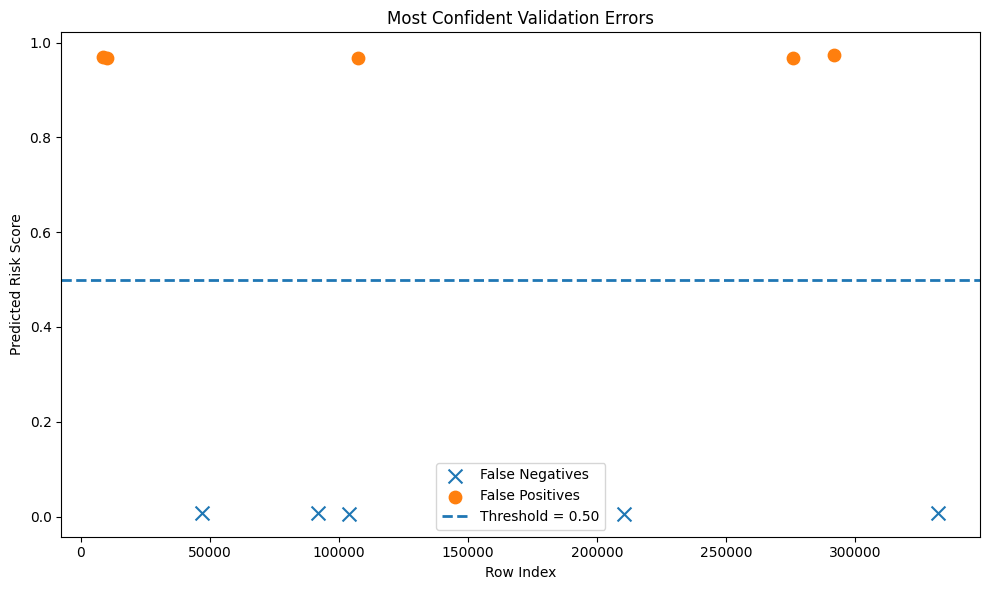

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    false_negatives.index,
    false_negatives["predicted_prob"],
    label="False Negatives",
    marker="x",
    s=100
)

ax.scatter(
    false_positives.index,
    false_positives["predicted_prob"],
    label="False Positives",
    marker="o",
    s=80
)

ax.axhline(champion_threshold, linestyle="--", linewidth=2, label=f"Threshold = {champion_threshold:.2f}")
ax.set_xlabel("Row Index")
ax.set_ylabel("Predicted Risk Score")
ax.set_title("Most Confident Validation Errors")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Save Part D Outputs

The final tables can be exported for later use in slides or in the written report.

In [15]:
failure_summary_table.to_csv("partD_failure_summary_table.csv", index=False)
proposed_fixes.to_csv("partD_proposed_fixes.csv", index=False)
false_negatives.to_csv("partD_top_false_negatives.csv", index=True)
false_positives.to_csv("partD_top_false_positives.csv", index=True)

print("Saved:")
print("  partD_failure_summary_table.csv")
print("  partD_proposed_fixes.csv")
print("  partD_top_false_negatives.csv")
print("  partD_top_false_positives.csv")

Saved:
  partD_failure_summary_table.csv
  partD_proposed_fixes.csv
  partD_top_false_negatives.csv
  partD_top_false_positives.csv
